In [18]:
# 1. List of all fednews_themes (in order)
fednews_themes = [
    "Emotional response",
    "Post-layoff precarities",
    "Career trajectory",
    "Collective resistance",
    "Individual survival strategy",
    "Weaponized system",
    "Weaponizing vulnerability"
]

# 2. List of all codes (in order of fednews_themes)
fednews_all_codes = [
    # Emotional response
    "Fear/Anxiety",
    "Anger/Blame",
    "Indifference/Humor",
    "Confusion/Surprise",
    "Frustration/Disappointment",
    # Post-layoff precarities
    "Immigration limbo",
    "Family struggle",
    "Financial insecurity",
    "Professional identity collapse",
    # Career trajectory
    "Job-search friction",
    "Anticipation & job insecurity",
    "Career change",
    # Collective resistance
    "Resource-sharing",
    "Legal mobilization",
    "Organizing boycott/protest",
    "Solidarity and appreciation",
    "Whistleblowing",
    # Individual survival strategy
    "Job search",
    "Seeking legal advice",
    "Personal exit strategy",
    "Self documentation",
    # Weaponized system
    "Responsibility Obfuscation",
    "Compliance Weaponization",
    "Policy Gaslighting",
    # Weaponizing vulnerability
    "Probationary targeting",
    "Disability penalties",
    "Immigrant weaponization"
]

fednews_emotional_response = [
    "Fear/Anxiety",
    "Anger/Blame",
    "Indifference/Humor",
    "Confusion/Surprise",
    "Frustration/Disappointment"
]
fednews_post_layoff_precarities = [
    "Immigration limbo",
    "Family struggle",
    "Financial insecurity",
    "Professional identity collapse"
]
fednews_career_trajectory = [
    "Job-search friction",
    "Anticipation & job insecurity",
    "Career change"
]
fednews_collective_resistance = [
    "Resource-sharing",
    "Legal mobilization",
    "Organizing boycott/protest",
    "Solidarity and appreciation",
    "Whistleblowing"
]
fednews_individual_survival_strategy = [
    "Job search",
    "Seeking legal advice",
    "Personal exit strategy",
    "Self documentation"
]
fednews_weaponized_system = [
    "Responsibility Obfuscation",
    "Compliance Weaponization",
    "Policy Gaslighting"
]
fednews_weaponizing_vulnerability = [
    "Probationary targeting",
    "Disability penalties",
    "Immigrant weaponization"
]

In [13]:
import json
jsonl_file = "fednews_10k_posts_with_post_id_and_labels.jsonl"  # Replace with your actual file path

code_set = set()

with open(jsonl_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            try:
                entry = json.loads(line)
                for code in entry.get("codes", []):
                    code_set.add(code)
            except json.JSONDecodeError:
                print("Error decoding JSON line:", line.strip())
                continue
# Final output
print("Unique Codes Found:")
for code in sorted(code_set):
    print("-", code)
print(f"\nTotal unique codes: {len(code_set)}")


Unique Codes Found:
- Anger/Blame
- Anticipation & job insecurity
- Career change
- Compliance Weaponization
- Confusion/Surprise
- Disability penalties
- Family struggle
- Fear/Anxiety
- Financial insecurity
- Frustration/Disappointment
- Immigrant weaponization
- Immigration limbo
- Indifference/Humor
- Job search
- Job-search friction
- Legal mobilization
- Organizing boycott/protest
- Personal exit strategy
- Policy Gaslighting
- Probationary targeting
- Professional identity collapse
- Resource-sharing
- Responsibility Obfuscation
- Seeking legal advice
- Self documentation
- Solidarity and appreciation
- Whistleblowing

Total unique codes: 27


## checking for missing code

In [14]:
missing_codes = code_set - set(fednews_all_codes)  # Codes in code_set but not in fednews_all_codes
print(f"Missing Codes: {missing_codes}")

Missing Codes: set()


In [11]:
import json

# file path to your jsonl file
#file_path = "your_file.jsonl"

# missing codes you mentioned
missing_codes = {
    "Individual survival strategy"
}

# store results as {code: [post_ids]}
code_to_posts = {code: [] for code in missing_codes}

with open(jsonl_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        post_id = data.get("post_id")
        codes = data.get("codes", [])
        
        for code in codes:
            if code in missing_codes:
                code_to_posts[code].append(post_id)

# print results
for code, posts in code_to_posts.items():
    print(f"{code}: {posts}")


Individual survival strategy: []


## visuals

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# === Step 1: Load JSONL file ===
# Replace with your actual file path
jsonl_file = "fednews_10k_posts_with_post_id_and_labels.jsonl"

df = pd.read_json(jsonl_file, lines=True)

# Ensure 'date' is datetime and derive 'month'
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

/tmp/ipykernel_268288/1074575790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")


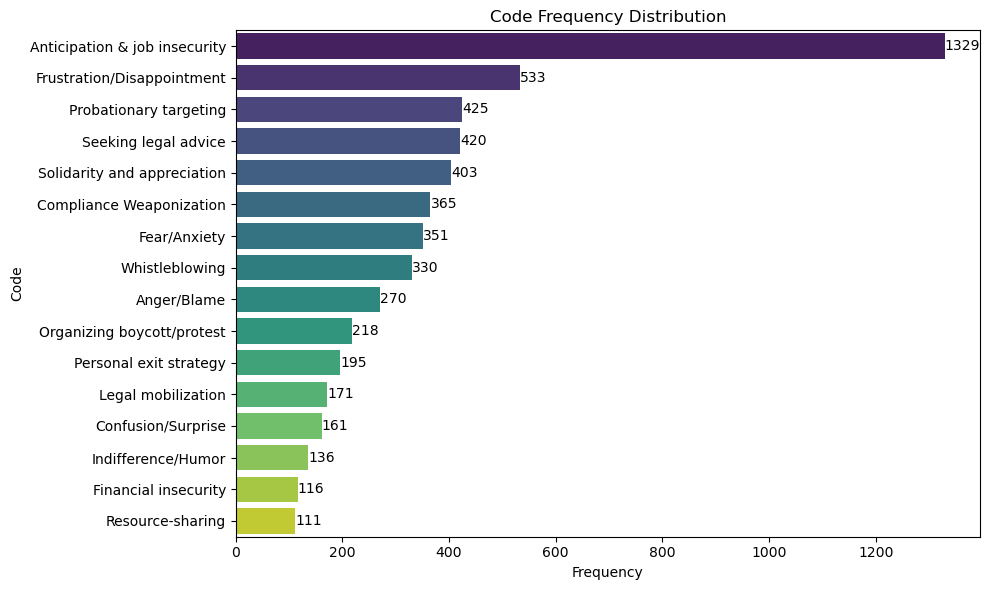

codes
Anticipation & job insecurity    1329
Frustration/Disappointment        533
Probationary targeting            425
Seeking legal advice              420
Solidarity and appreciation       403
Compliance Weaponization          365
Fear/Anxiety                      351
Whistleblowing                    330
Anger/Blame                       270
Organizing boycott/protest        218
Personal exit strategy            195
Legal mobilization                171
Confusion/Surprise                161
Indifference/Humor                136
Financial insecurity              116
Resource-sharing                  111
Name: count, dtype: int64


/tmp/ipykernel_268288/1074575790.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")


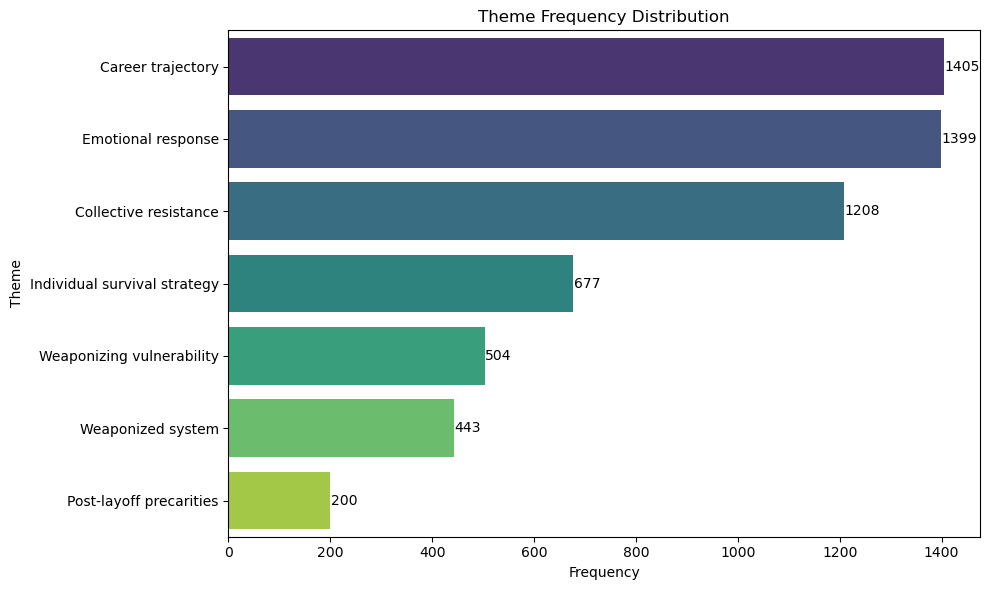

themes
Career trajectory               1405
Emotional response              1399
Collective resistance           1208
Individual survival strategy     677
Weaponizing vulnerability        504
Weaponized system                443
Post-layoff precarities          200
Name: count, dtype: int64


In [3]:



# Code frequency bar chart
fednews_all_codes = df['codes'].explode()
code_freq = fednews_all_codes.value_counts().sort_values(ascending=False)
code_freq.to_csv("code_frequency.csv", header=True)
# only keep codes with more than 100 occurrences
code_freq = code_freq[code_freq > 100]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")
plt.title("Code Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Code")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(code_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(code_freq)



# theme frequency bar chart
all_fednews_themes = df['themes'].explode()
theme_freq = all_fednews_themes.value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")
plt.title("Theme Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Theme")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(theme_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(theme_freq)


# save theme frequency to CSV
theme_freq.to_csv("theme_frequency.csv", header=True)


/tmp/ipykernel_120749/3767850500.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=theme_freq['count'], y=theme_freq.index, palette="viridis")


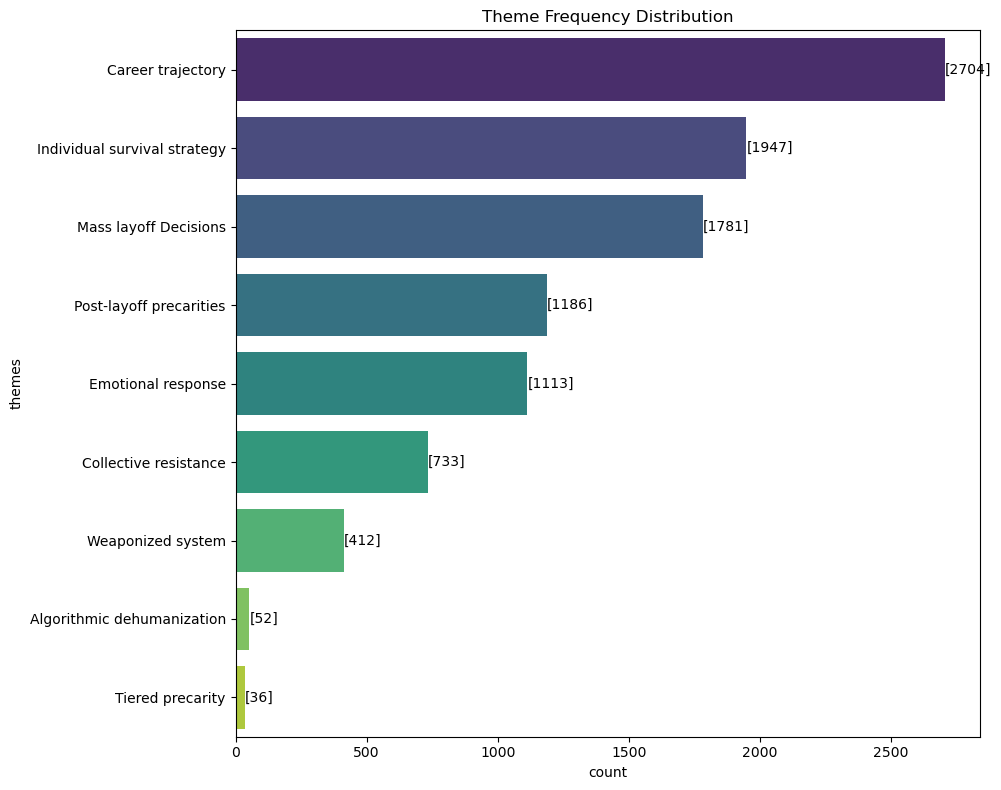

In [8]:
## generate theme frequency bar chart from theme_frequency.csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load theme frequency data
theme_freq = pd.read_csv("theme_frequency.csv", index_col=0)
theme_freq = theme_freq.sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=theme_freq['count'], y=theme_freq.index, palette="viridis")
plt.title("Theme Frequency Distribution")
# plt.xlabel("Frequency")
# plt.ylabel("Theme")
plt.tight_layout()  

for i, v in enumerate(theme_freq.values):
    ax.text(v + 0.8, i, str(v), color='black', va='center')

plt.show()

In [23]:
import numpy as np
# Initialize empty co-occurrence matrix
co_occurrence = pd.DataFrame(0, index=fednews_all_codes, columns=fednews_all_codes)

# Fill matrix from code list per post
for code_list in df['codes']:
    for c1, c2 in combinations(code_list, 2):
        co_occurrence.at[c1, c2] += 1
        co_occurrence.at[c2, c1] += 1
    for c in code_list:
        co_occurrence.at[c, c] += 1  # include diagonal

print("Co-occurrence matrix shape:", co_occurrence.shape)
# save the co-occurrence matrix to CSV
co_occurrence.to_csv("co_occurrence_matrix.csv", header=True)

# Apply log scale for better contrast
log_scaled = np.log1p(co_occurrence)

# Create mask for upper triangle
mask = np.tril(np.ones_like(log_scaled, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(log_scaled, mask=mask, cmap="YlGnBu", square=True,
            linewidths=0.5, cbar_kws={"label": "log(1 + count)"})
plt.title("Code Co-occurrence Heatmap (log scale, lower triangle)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [25]:
# === Step 5: Monthly Trends for Selected Codes ===

def plot_monthly_trends(df, sample_codes):
    df_exploded = df.explode('codes')
    monthly_trends = (
        df_exploded[df_exploded['codes'].isin(sample_codes)]
        .groupby(['month', 'codes'])
        .size()
        .unstack(fill_value=0)
    )

    monthly_trends.plot(kind='line', marker='o', figsize=(10, 6))
    plt.title("Monthly Trends of Selected Codes")
    plt.xlabel("Month")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

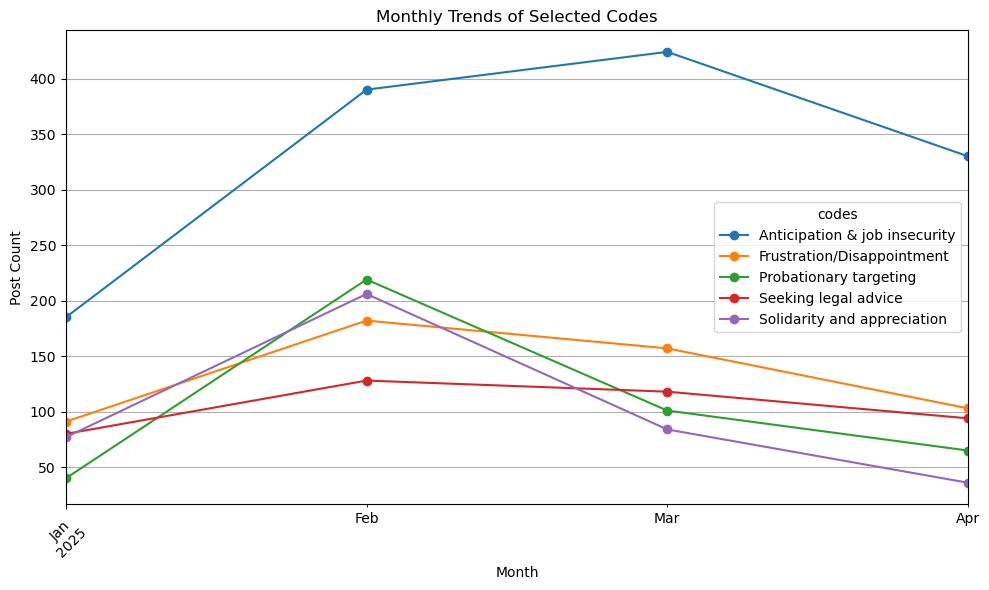

In [28]:
top_5_codes = ["Anticipation & job insecurity", "Frustration/Disappointment", "Probationary targeting", "Seeking legal advice", "Solidarity and appreciation"]
plot_monthly_trends(df, top_5_codes)


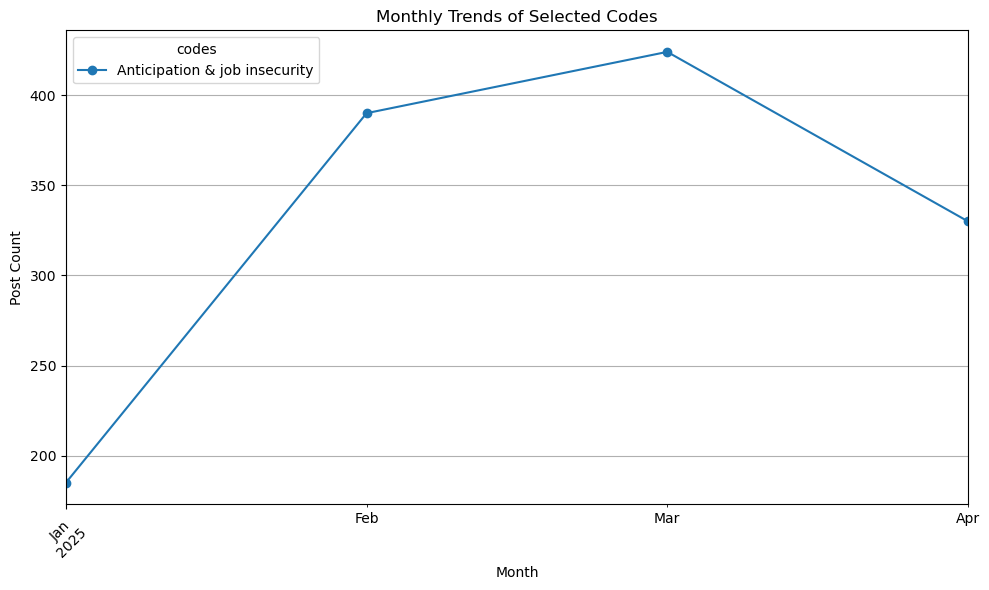

In [27]:
# digging deeper
top_2_codes = ["Anticipation & job insecurity", "News of mass layoff"]
plot_monthly_trends(df, top_2_codes)

## special stacked image

In [4]:
###
sorted_fednews_theme_dict = {
    "Career trajectory": {
        "count": 1405,
        "codes": {
            "Anticipation & job insecurity": 1329,
            "Career change": 77,
            "Job-search friction": 50,
        },
    },
    "Emotional response": {
        "count": 1399,
        "codes": {
            "Frustration/Disappointment": 533,
            "Fear/Anxiety": 351,
            "Anger/Blame": 270,
            "Confusion/Surprise": 161,
            "Indifference/Humor": 136,
        },
    },
    "Collective resistance": {
        "count": 1208,
        "codes": {
            "Solidarity and appreciation": 403,
            "Whistleblowing": 330,
            "Organizing boycott/protest": 218,
            "Legal mobilization": 171,
            "Resource-sharing": 111,
        },
    },
    "Individual survival strategy": {
        "count": 677,
        "codes": {
            "Seeking legal advice": 420,
            "Personal exit strategy": 195,
            "Self documentation": 50,
            "Job search": 22,
        },
    },
    "Weaponizing vulnerability": {
        "count": 504,
        "codes": {
            "Probationary targeting": 425,
            "Disability penalties": 75,
            "Immigrant weaponization": 6,
        },
    },
    "Weaponized system": {
        "count": 443,
        "codes": {
            "Compliance Weaponization": 365,
            "Policy Gaslighting": 56,
            "Responsibility Obfuscation": 25,
        },
    },
    "Post-layoff precarities": {
        "count": 200,
        "codes": {
            "Financial insecurity": 116,
            "Family struggle": 60,
            "Professional identity collapse": 31,
            "Immigration limbo": 1,
        },
    },
}


In [ ]:
## code sum count will be greater than theme count because we used multi code labeling.
def report_theme_code_mismatches(data):
    for theme, info in data.items():
        theme_total = int(info.get("count", 0))
        code_total = sum(int(v) for v in info.get("codes", {}).values())
        if code_total != theme_total:
            print(f"{theme}: theme_count={theme_total}, sum_codes={code_total}, diff={code_total - theme_total}")

# run:
report_theme_code_mismatches(sorted_fednews_theme_dict)


Career trajectory: theme_count=1405, sum_codes=1456, diff=51
Emotional response: theme_count=1399, sum_codes=1451, diff=52
Collective resistance: theme_count=1208, sum_codes=1233, diff=25
Individual survival strategy: theme_count=677, sum_codes=687, diff=10
Weaponizing vulnerability: theme_count=504, sum_codes=506, diff=2
Weaponized system: theme_count=443, sum_codes=446, diff=3
Post-layoff precarities: theme_count=200, sum_codes=208, diff=8


/tmp/ipykernel_268288/1237394397.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  theme_color_map = plt.cm.get_cmap("tab10", len(themes_sorted))


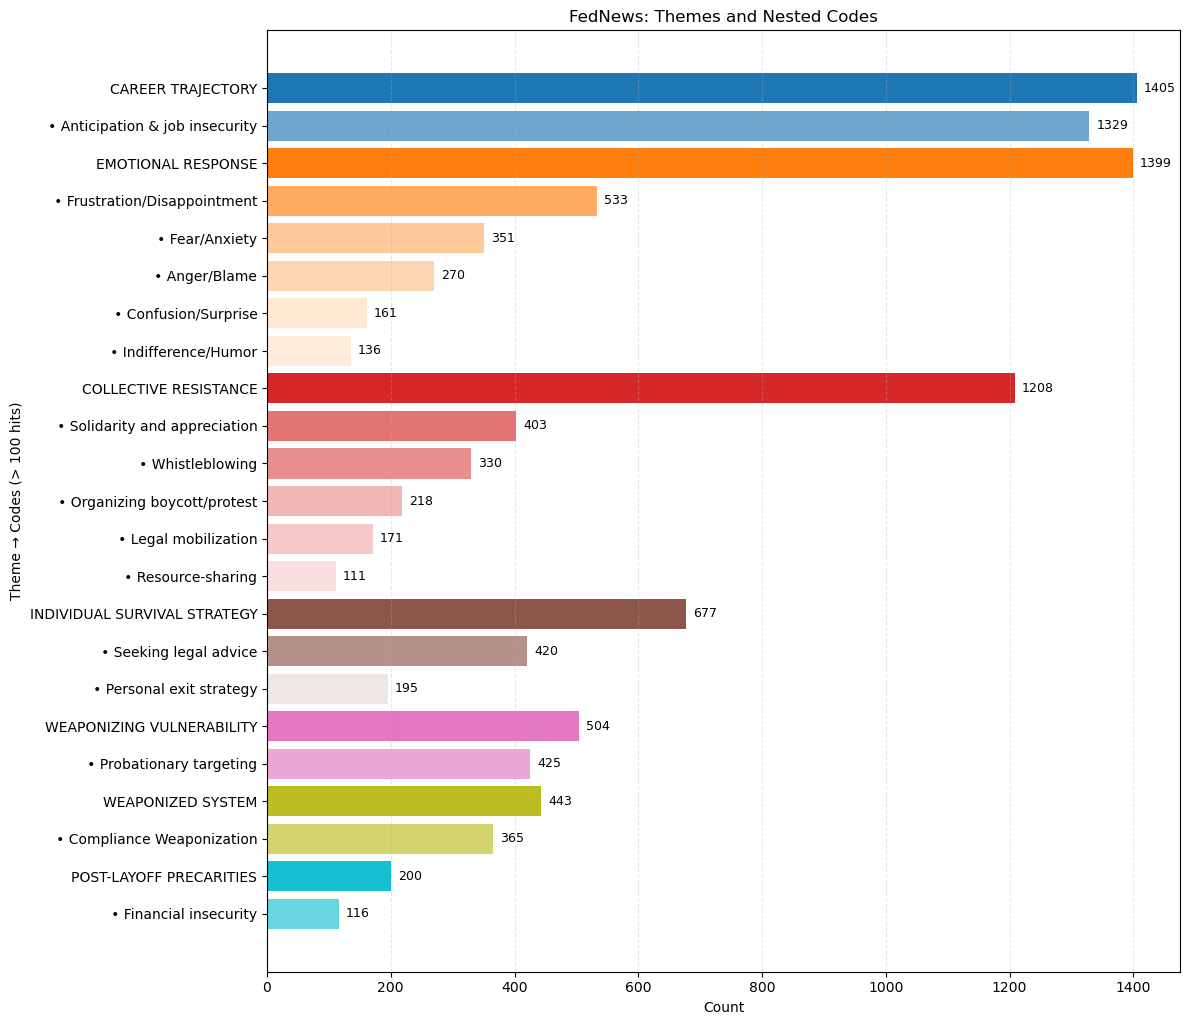

Saved to fednews_theme_codes.png


In [7]:
# --- Data (sorted by theme & code counts) ---
sorted_fednews_theme_dict = {
    "Career trajectory": {
        "count": 1405,
        "codes": {
            "Anticipation & job insecurity": 1329,
            "Career change": 77,
            "Job-search friction": 50,
        },
    },
    "Emotional response": {
        "count": 1399,
        "codes": {
            "Frustration/Disappointment": 533,
            "Fear/Anxiety": 351,
            "Anger/Blame": 270,
            "Confusion/Surprise": 161,
            "Indifference/Humor": 136,
        },
    },
    "Collective resistance": {
        "count": 1208,
        "codes": {
            "Solidarity and appreciation": 403,
            "Whistleblowing": 330,
            "Organizing boycott/protest": 218,
            "Legal mobilization": 171,
            "Resource-sharing": 111,
        },
    },
    "Individual survival strategy": {
        "count": 677,
        "codes": {
            "Seeking legal advice": 420,
            "Personal exit strategy": 195,
            "Self documentation": 50,
            "Job search": 22,
        },
    },
    "Weaponizing vulnerability": {
        "count": 504,
        "codes": {
            "Probationary targeting": 425,
            "Disability penalties": 75,
            "Immigrant weaponization": 6,
        },
    },
    "Weaponized system": {
        "count": 443,
        "codes": {
            "Compliance Weaponization": 365,
            "Policy Gaslighting": 56,
            "Responsibility Obfuscation": 25,
        },
    },
    "Post-layoff precarities": {
        "count": 200,
        "codes": {
            "Financial insecurity": 116,
            "Family struggle": 60,
            "Professional identity collapse": 31,
            "Immigration limbo": 1,
        },
    },
}

# --- Params you can tweak ---
TOP_N_THEMES = 7               # how many themes to plot (sorted by count desc)
CODE_MIN_COUNT = 100           # keep codes with count > CODE_MIN_COUNT
OUTPUT_PNG = "fednews_theme_codes.png"

# --- Plot ---
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

def mix_with_white(rgb, t):
    """t in [0,1]; 0 = original rgb, 1 = white; returns lighter color."""
    r, g, b = rgb
    return (r*(1-t) + 1*t, g*(1-t) + 1*t, b*(1-t) + 1*t)

# Select top-N themes by count
themes_sorted = sorted(sorted_fednews_theme_dict.items(), key=lambda kv: kv[1]["count"], reverse=True)[:TOP_N_THEMES]

# Prepare plotting lists
labels, values, colors = [], [], []
theme_color_map = plt.cm.get_cmap("tab10", len(themes_sorted))

for i, (theme, info) in enumerate(themes_sorted):
    base_rgb = to_rgb(theme_color_map(i))
    # Theme bar
    labels.append(theme.upper())
    values.append(info["count"])
    colors.append(base_rgb)

    # Codes: filter & sort by count desc
    codes = {k: v for k, v in info["codes"].items() if v > CODE_MIN_COUNT}
    codes_sorted = sorted(codes.items(), key=lambda kv: kv[1], reverse=True)

    if codes_sorted:
        code_counts = [v for _, v in codes_sorted]
        cmin, cmax = min(code_counts), max(code_counts)
        for code, cnt in codes_sorted:
            # intensity based on count within this theme (always lighter than theme)
            if cmax > cmin:
                norm = (cnt - cmin) / (cmax - cmin)  # 0..1 (low..high)
            else:
                norm = 1.0
            t = 0.35 + 0.50 * (1 - norm)  # high count -> smaller t (more intense); all < theme intensity
            labels.append(f"   • {code}")
            values.append(cnt)
            colors.append(mix_with_white(base_rgb, t))

# Figure height scales with number of bars
fig_h = max(4, 0.45 * len(labels))
plt.figure(figsize=(12, fig_h))

ypos = range(len(labels))
bars = plt.barh(list(ypos), values, color=colors, edgecolor="none")

# Value labels
for y, v in zip(ypos, values):
    plt.text(v + max(values)*0.008, y, f"{v}", va="center", fontsize=9)

plt.gca().invert_yaxis()
plt.xlabel("Count")
plt.ylabel("Theme → Codes (> {} hits)".format(CODE_MIN_COUNT))
plt.title("FedNews: Themes and Nested Codes")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.yticks(list(ypos), labels)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_PNG}")


/tmp/ipykernel_334536/1179934421.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))


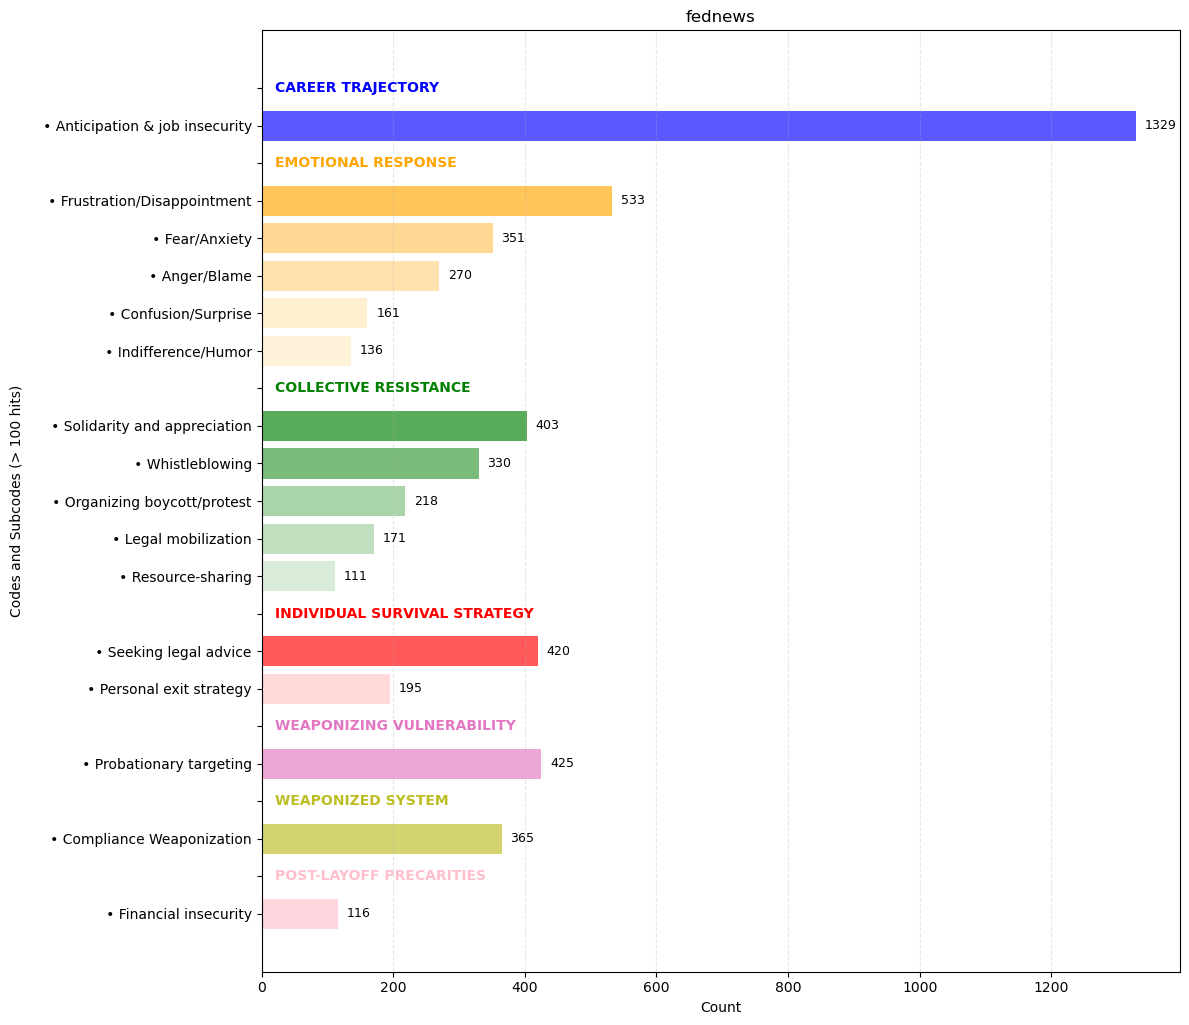

Saved to fednews_theme_codes.png


In [2]:
sorted_fednews_theme_dict = {
    "Career trajectory": {
        "count": 1405,
        "codes": {
            "Anticipation & job insecurity": 1329,
            "Career change": 77,
            "Job-search friction": 50,
        },
    },
    "Emotional response": {
        "count": 1399,
        "codes": {
            "Frustration/Disappointment": 533,
            "Fear/Anxiety": 351,
            "Anger/Blame": 270,
            "Confusion/Surprise": 161,
            "Indifference/Humor": 136,
        },
    },
    "Collective resistance": {
        "count": 1208,
        "codes": {
            "Solidarity and appreciation": 403,
            "Whistleblowing": 330,
            "Organizing boycott/protest": 218,
            "Legal mobilization": 171,
            "Resource-sharing": 111,
        },
    },
    "Individual survival strategy": {
        "count": 677,
        "codes": {
            "Seeking legal advice": 420,
            "Personal exit strategy": 195,
            "Self documentation": 50,
            "Job search": 22,
        },
    },
    "Weaponizing vulnerability": {
        "count": 504,
        "codes": {
            "Probationary targeting": 425,
            "Disability penalties": 75,
            "Immigrant weaponization": 6,
        },
    },
    "Weaponized system": {
        "count": 443,
        "codes": {
            "Compliance Weaponization": 365,
            "Policy Gaslighting": 56,
            "Responsibility Obfuscation": 25,
        },
    },
    "Post-layoff precarities": {
        "count": 200,
        "codes": {
            "Financial insecurity": 116,
            "Family struggle": 60,
            "Professional identity collapse": 31,
            "Immigration limbo": 1,
        },
    },
}


# --- Params you can tweak ---
subreddit = "fednews"
TOP_N_THEMES = 7                 # how many themes to show (sorted by count desc)
CODE_MIN_COUNT = 100             # filter codes with count <= threshold
OUTPUT_PNG = f"{subreddit}_theme_codes.png"
THEME_LABEL_X_FRAC = 0.015       # theme text x-position as fraction of max count (inside plot)

# --- Plot ---
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

THEME_COLOR_SPEC = {
    "Emotional response": "orange",
    "Post-layoff precarities": "pink",
    "Career trajectory": "blue",
    "Collective resistance": "green",
    "Individual survival strategy": "red",
}

def mix_with_white(rgb, t):
    r, g, b = rgb
    return (r*(1-t) + 1*t, g*(1-t) + 1*t, b*(1-t) + 1*t)

themes_sorted = sorted(
    sorted_fednews_theme_dict.items(),
    key=lambda kv: kv[1]["count"],
    reverse=True
)[:TOP_N_THEMES]

labels, values, colors, is_header = [], [], [], []
groups = []  # store header row index for each theme
fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))

for i, (theme, info) in enumerate(themes_sorted):
    base_rgb = to_rgb(THEME_COLOR_SPEC.get(theme, fallback_cmap(i)))

    # header row (no bar) for this theme
    header_idx = len(labels)
    labels.append(theme)
    values.append(0)
    colors.append("none")
    is_header.append(True)

    # codes
    codes = {k: v for k, v in info["codes"].items() if v > CODE_MIN_COUNT}
    codes_sorted = sorted(codes.items(), key=lambda kv: kv[1], reverse=True)

    if codes_sorted:
        code_counts = [v for _, v in codes_sorted]
        cmin, cmax = min(code_counts), max(code_counts)
        for code, cnt in codes_sorted:
            norm = (cnt - cmin) / (cmax - cmin) if cmax > cmin else 1.0
            t = 0.35 + 0.50 * (1 - norm)  # lighter for lower counts
            labels.append(f"   • {code}")
            values.append(cnt)
            colors.append(mix_with_white(base_rgb, t))
            is_header.append(False)

    groups.append({"theme": theme.upper(), "color": base_rgb, "header": header_idx})

# ----- Render -----
fig_h = max(4, 0.45 * len(labels))
fig, ax = plt.subplots(figsize=(12, fig_h))
ypos = list(range(len(labels)))
bars = ax.barh(ypos, values, color=colors, edgecolor="none")

# annotate counts for code rows
if values:
    xmax = max(values) if max(values) > 0 else 1
    for y, v, hdr in zip(ypos, values, is_header):
        if not hdr and v > 0:
            ax.text(v + xmax * 0.01, y, f"{v}", va="center", fontsize=9)

# THEME NAMES: place on the header row (above its group's bars)
x_text = (max(values) if values else 1) * THEME_LABEL_X_FRAC
for g in groups:
    ax.text(x_text, g["header"], g["theme"], va="center", ha="left",
            fontweight="bold", color=g["color"])

# hide header ticks; keep only code labels
yticklabels = [("" if hdr else lbl) for lbl, hdr in zip(labels, is_header)]
ax.set_yticks(ypos)
ax.set_yticklabels(yticklabels)

ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_ylabel(f"Codes and Subcodes (> {CODE_MIN_COUNT} hits)")
ax.set_title(f"{subreddit}")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_PNG}")


/tmp/ipykernel_484271/3071446426.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))


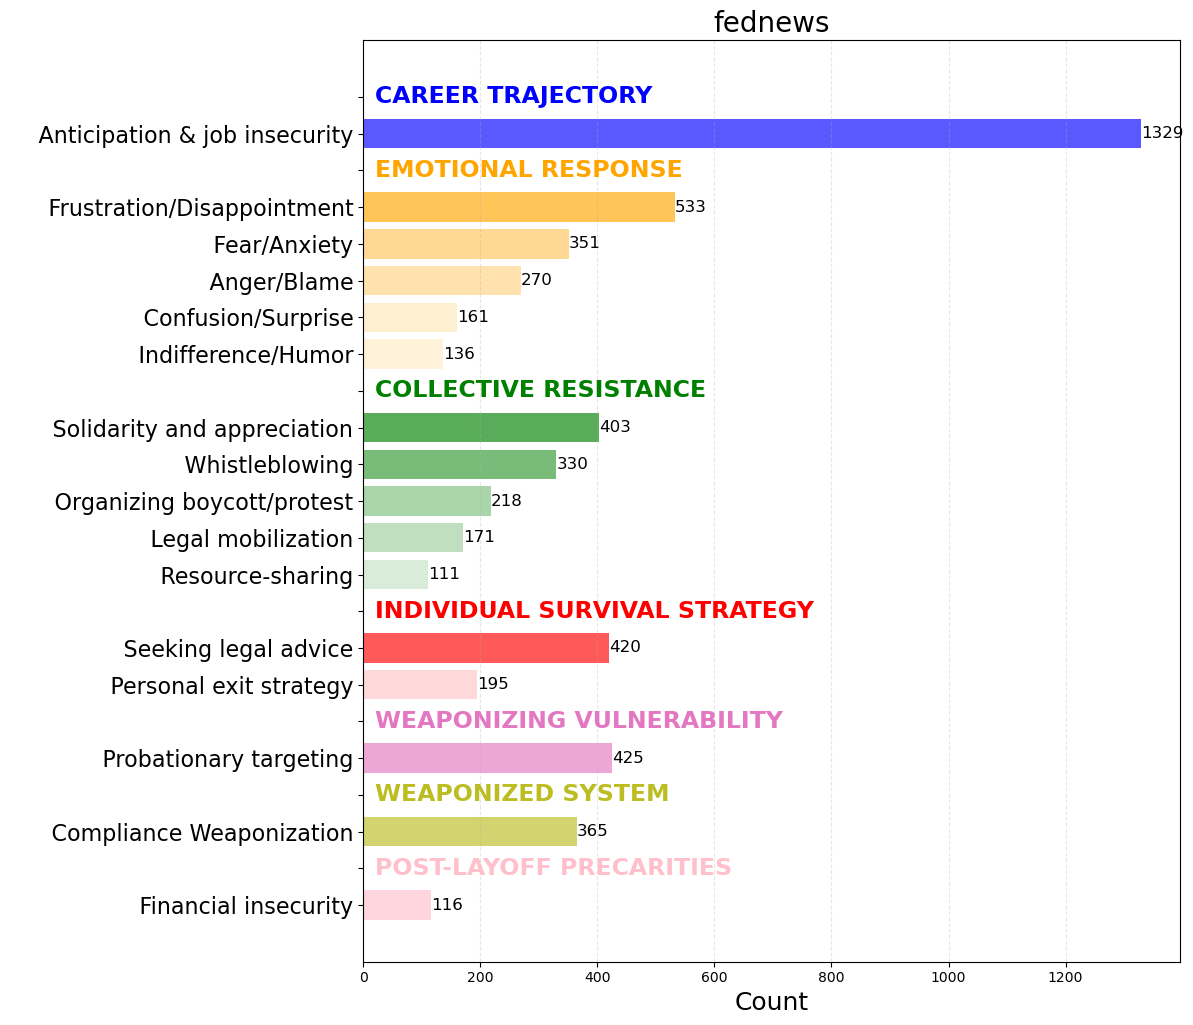

Saved to fednews_theme_codes.png


In [1]:
sorted_fednews_theme_dict = {
    "Career trajectory": {
        "count": 1405,
        "codes": {
            "Anticipation & job insecurity": 1329,
            "Career change": 77,
            "Job-search friction": 50,
        },
    },
    "Emotional response": {
        "count": 1399,
        "codes": {
            "Frustration/Disappointment": 533,
            "Fear/Anxiety": 351,
            "Anger/Blame": 270,
            "Confusion/Surprise": 161,
            "Indifference/Humor": 136,
        },
    },
    "Collective resistance": {
        "count": 1208,
        "codes": {
            "Solidarity and appreciation": 403,
            "Whistleblowing": 330,
            "Organizing boycott/protest": 218,
            "Legal mobilization": 171,
            "Resource-sharing": 111,
        },
    },
    "Individual survival strategy": {
        "count": 677,
        "codes": {
            "Seeking legal advice": 420,
            "Personal exit strategy": 195,
            "Self documentation": 50,
            "Job search": 22,
        },
    },
    "Weaponizing vulnerability": {
        "count": 504,
        "codes": {
            "Probationary targeting": 425,
            "Disability penalties": 75,
            "Immigrant weaponization": 6,
        },
    },
    "Weaponized system": {
        "count": 443,
        "codes": {
            "Compliance Weaponization": 365,
            "Policy Gaslighting": 56,
            "Responsibility Obfuscation": 25,
        },
    },
    "Post-layoff precarities": {
        "count": 200,
        "codes": {
            "Financial insecurity": 116,
            "Family struggle": 60,
            "Professional identity collapse": 31,
            "Immigration limbo": 1,
        },
    },
}


# --- Params you can tweak (NEW) ---
subreddit = "fednews"
TOP_N_THEMES = 7
CODE_MIN_COUNT = 100
OUTPUT_PNG = f"{subreddit}_theme_codes.png"
THEME_LABEL_X_FRAC = 0.015

# font sizes (NEW)
TITLE_FONTSIZE = 20
AXIS_LABEL_FONTSIZE = 18
YTICK_FONTSIZE = 16          # codes/subcodes size
THEME_FONTSIZE = 17          # theme names inside plot
COUNT_FONTSIZE = 12          # numbers at bar ends

# subcode label formatting (NEW)
INDENT = "    "              # spaces before subcodes
SUBCODE_PREFIX = ""          # set to "• " to bring bullets back

# --- Plot ---
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

THEME_COLOR_SPEC = {
    "Emotional response": "orange",
    "Post-layoff precarities": "pink",
    "Career trajectory": "blue",
    "Collective resistance": "green",
    "Individual survival strategy": "red",
}

def mix_with_white(rgb, t):
    r, g, b = rgb
    return (r*(1-t) + 1*t, g*(1-t) + 1*t, b*(1-t) + 1*t)

themes_sorted = sorted(
    sorted_fednews_theme_dict.items(),
    key=lambda kv: kv[1]["count"],
    reverse=True
)[:TOP_N_THEMES]

labels, values, colors, is_header = [], [], [], []
groups = []
fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))

for i, (theme, info) in enumerate(themes_sorted):
    base_rgb = to_rgb(THEME_COLOR_SPEC.get(theme, fallback_cmap(i)))

    # header row (no bar)
    header_idx = len(labels)
    labels.append(theme)             # (unchanged)
    values.append(0)
    colors.append("none")
    is_header.append(True)

    # codes
    codes = {k: v for k, v in info["codes"].items() if v > CODE_MIN_COUNT}
    codes_sorted = sorted(codes.items(), key=lambda kv: kv[1], reverse=True)

    if codes_sorted:
        code_counts = [v for _, v in codes_sorted]
        cmin, cmax = min(code_counts), max(code_counts)
        for code, cnt in codes_sorted:
            norm = (cnt - cmin) / (cmax - cmin) if cmax > cmin else 1.0
            t = 0.35 + 0.50 * (1 - norm)
            # ↓ CHANGED: remove bullet, keep indent; configurable via INDENT/SUBCODE_PREFIX
            labels.append(f"{INDENT}{SUBCODE_PREFIX}{code}")
            values.append(cnt)
            colors.append(mix_with_white(base_rgb, t))
            is_header.append(False)

    groups.append({"theme": theme.upper(), "color": base_rgb, "header": header_idx})

# ----- Render -----
fig_h = max(4, 0.45 * len(labels))
fig, ax = plt.subplots(figsize=(12, fig_h))
ypos = list(range(len(labels)))
bars = ax.barh(ypos, values, color=colors, edgecolor="none")

# annotate counts
if values:
    xmax = max(values) if max(values) > 0 else 1
    for y, v, hdr in zip(ypos, values, is_header):
        if not hdr and v > 0:
            #ax.text(v + xmax * 0.01, y, f"{v}", va="center", fontsize=COUNT_FONTSIZE)  # CHANGED
            ax.annotate(f"{v}", xy=(v, y), xytext=(0, 0), textcoords="offset points",
            va="center", ha="left", fontsize=COUNT_FONTSIZE)


# theme names on header rows (CHANGED: use THEME_FONTSIZE)
x_text = (max(values) if values else 1) * THEME_LABEL_X_FRAC
for g in groups:
    ax.text(x_text, g["header"], g["theme"], va="center", ha="left",
            fontweight="bold", color=g["color"], fontsize=THEME_FONTSIZE)

# y-tick labels (CHANGED: bigger fonts; headers hidden)
yticklabels = [("" if hdr else lbl) for lbl, hdr in zip(labels, is_header)]
ax.set_yticks(ypos)
ax.set_yticklabels(yticklabels, fontsize=YTICK_FONTSIZE)  # CHANGED

ax.invert_yaxis()
ax.set_xlabel("Count", fontsize=AXIS_LABEL_FONTSIZE)      # CHANGED
ax.set_title(f"{subreddit}", fontsize=TITLE_FONTSIZE)     # CHANGED
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_PNG}")


## by deepseek

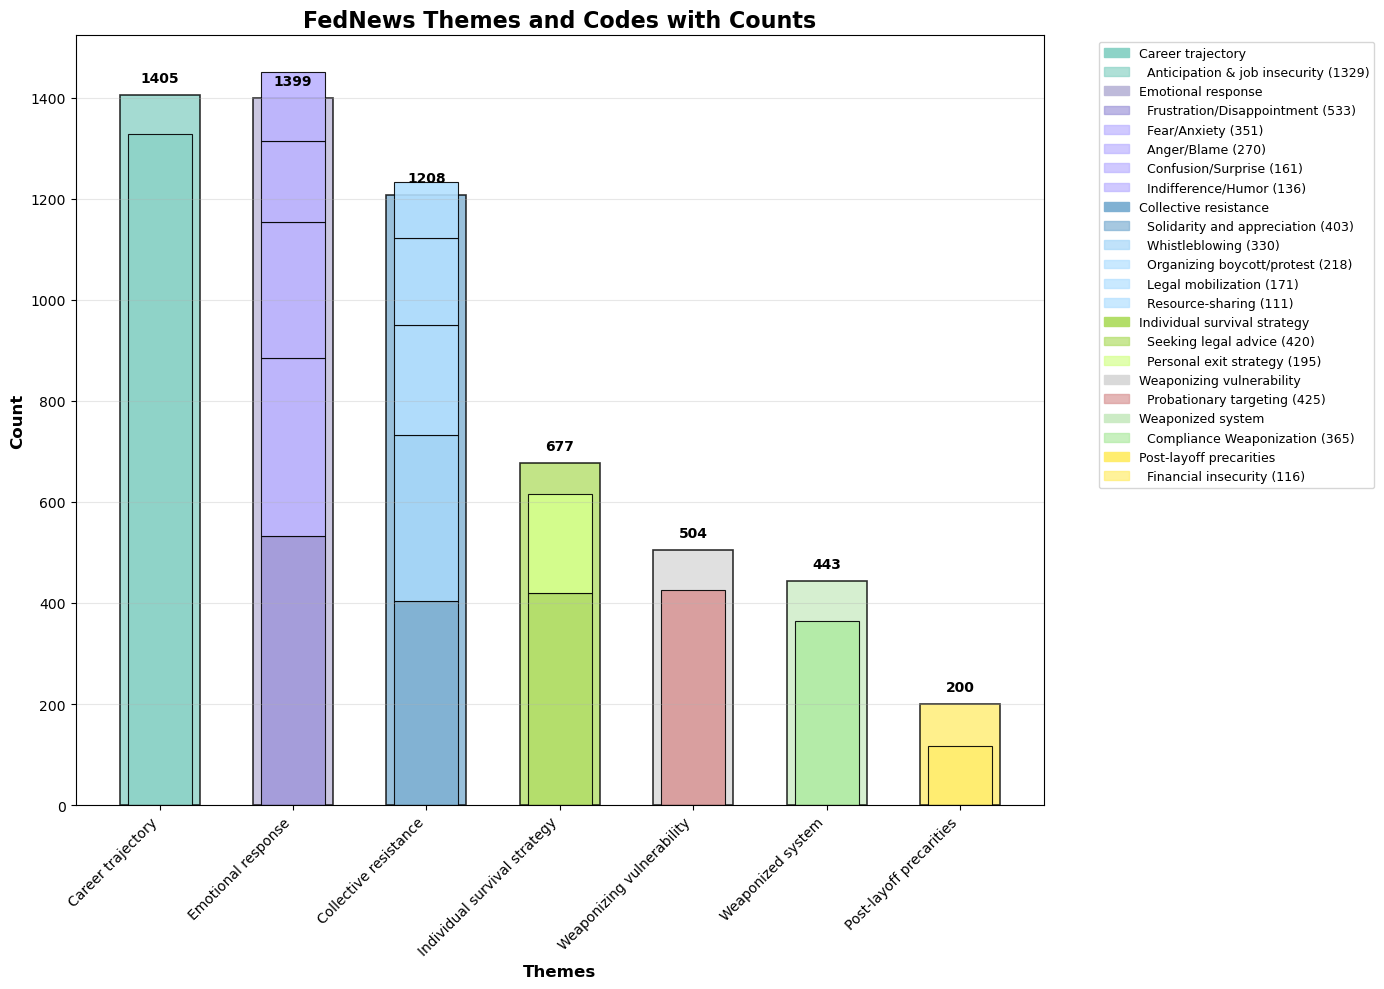

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import colorsys

# Your data
sorted_fednews_theme_dict = {
    "Career trajectory": {
        "count": 1405,
        "codes": {
            "Anticipation & job insecurity": 1329,
            "Career change": 77,
            "Job-search friction": 50,
        },
    },
    "Emotional response": {
        "count": 1399,
        "codes": {
            "Frustration/Disappointment": 533,
            "Fear/Anxiety": 351,
            "Anger/Blame": 270,
            "Confusion/Surprise": 161,
            "Indifference/Humor": 136,
        },
    },
    "Collective resistance": {
        "count": 1208,
        "codes": {
            "Solidarity and appreciation": 403,
            "Whistleblowing": 330,
            "Organizing boycott/protest": 218,
            "Legal mobilization": 171,
            "Resource-sharing": 111,
        },
    },
    "Individual survival strategy": {
        "count": 677,
        "codes": {
            "Seeking legal advice": 420,
            "Personal exit strategy": 195,
            "Self documentation": 50,
            "Job search": 22,
        },
    },
    "Weaponizing vulnerability": {
        "count": 504,
        "codes": {
            "Probationary targeting": 425,
            "Disability penalties": 75,
            "Immigrant weaponization": 6,
        },
    },
    "Weaponized system": {
        "count": 443,
        "codes": {
            "Compliance Weaponization": 365,
            "Policy Gaslighting": 56,
            "Responsibility Obfuscation": 25,
        },
    },
    "Post-layoff precarities": {
        "count": 200,
        "codes": {
            "Financial insecurity": 116,
            "Family struggle": 60,
            "Professional identity collapse": 31,
            "Immigration limbo": 1,
        },
    },
}

# Configuration variables
num_themes = 7  # Number of themes to display (max is 7)
min_code_count = 100  # Minimum count for codes to be displayed

# Filter themes and codes based on configuration
filtered_themes = {}
for i, (theme, data) in enumerate(sorted_fednews_theme_dict.items()):
    if i >= num_themes:
        break
        
    filtered_codes = {code: count for code, count in data['codes'].items() 
                     if count >= min_code_count}
    
    # Only include theme if it has at least one code meeting the threshold
    if filtered_codes:
        filtered_themes[theme] = {
            'count': data['count'],
            'codes': filtered_codes
        }

# Prepare data for plotting
themes = list(filtered_themes.keys())
theme_counts = [filtered_themes[theme]['count'] for theme in themes]
code_data = [filtered_themes[theme]['codes'] for theme in themes]

# Create a distinct color for each theme
base_colors = plt.cm.Set3(np.linspace(0, 1, len(themes)))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))

# Set positions for bars
bar_width = 0.6
theme_positions = np.arange(len(themes))
code_positions = []

# Plot theme bars
theme_bars = ax.bar(theme_positions, theme_counts, bar_width, 
                   color=base_colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# Plot code bars with varying intensities
for i, (theme_pos, codes) in enumerate(zip(theme_positions, code_data)):
    # Sort codes by count (descending)
    sorted_codes = sorted(codes.items(), key=lambda x: x[1], reverse=True)
    code_names = [code[0] for code in sorted_codes]
    code_counts = [code[1] for code in sorted_codes]
    
    # Create color gradient for codes
    base_color = base_colors[i]
    # Convert RGB to HSV to adjust value (brightness)
    r, g, b, a = base_color
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    
    # Create lighter colors for codes
    code_colors = []
    for j in range(len(code_counts)):
        # Decrease saturation and increase value for each subsequent code
        new_s = max(0.3, s * (1 - j * 0.15))
        new_v = min(1.0, v + j * 0.15)
        new_r, new_g, new_b = colorsys.hsv_to_rgb(h, new_s, new_v)
        code_colors.append((new_r, new_g, new_b, a))
    
    # Calculate positions for code bars (stacked on top of each other)
    code_bottom = 0
    code_rects = []
    
    for count, color in zip(code_counts, code_colors):
        rect = ax.bar(theme_pos, count, bar_width * 0.8, bottom=code_bottom, 
                     color=color, alpha=0.9, edgecolor='black', linewidth=0.8)
        code_rects.append(rect)
        code_bottom += count
    
    code_positions.append(code_rects)

# Add count labels on top of theme bars
for i, (rect, count) in enumerate(zip(theme_bars, theme_counts)):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 20,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Customize the plot
ax.set_xlabel('Themes', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('FedNews Themes and Codes with Counts', fontsize=16, fontweight='bold')
ax.set_xticks(theme_positions)
ax.set_xticklabels(themes, rotation=45, ha='right', fontsize=10)

# Add legend
legend_patches = []
for i, theme in enumerate(themes):
    legend_patches.append(mpatches.Patch(color=base_colors[i], label=theme))
    
    # Add code entries to legend
    codes = filtered_themes[theme]['codes']
    sorted_codes = sorted(codes.items(), key=lambda x: x[1], reverse=True)
    
    for code_name, code_count in sorted_codes:
        # Get the color for this code
        code_idx = list(codes.keys()).index(code_name)
        r, g, b, a = base_colors[i]
        h, s, v = colorsys.rgb_to_hsv(r, g, b)
        new_s = max(0.3, s * (1 - code_idx * 0.15))
        new_v = min(1.0, v + code_idx * 0.15)
        new_r, new_g, new_b = colorsys.hsv_to_rgb(h, new_s, new_v)
        code_color = (new_r, new_g, new_b, a)
        
        legend_patches.append(mpatches.Patch(
            color=code_color, 
            label=f"  {code_name} ({code_count})",
            alpha=0.7
        ))

ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Adjust layout to make room for legend
plt.tight_layout()

# Add grid for better readability
ax.grid(True, axis='y', alpha=0.3)

plt.show()

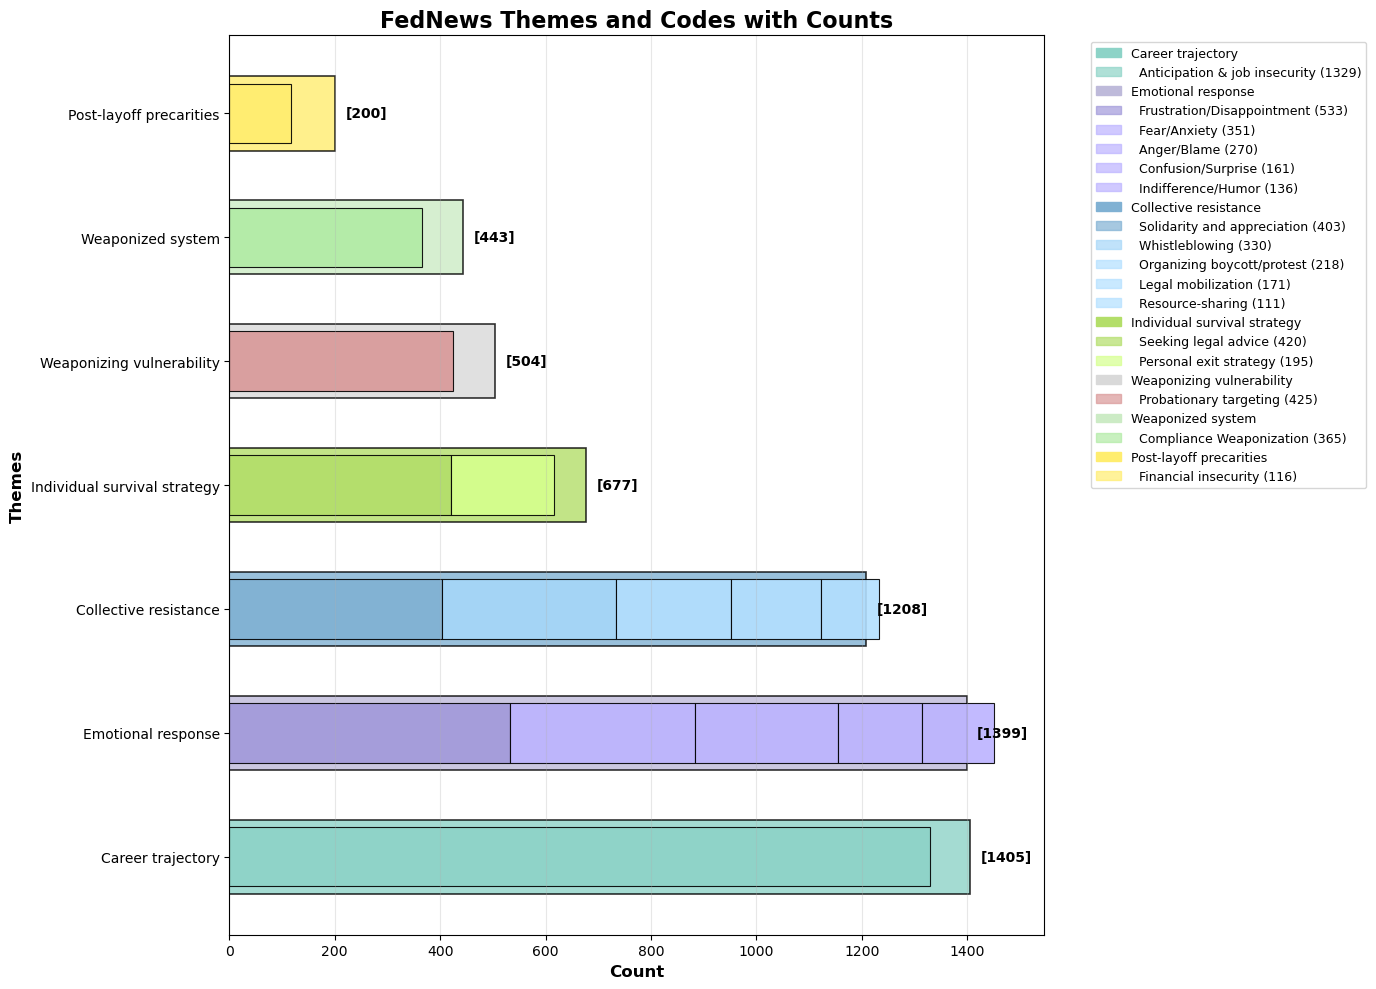

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import colorsys

# Your data
sorted_fednews_theme_dict = {
    "Career trajectory": {
        "count": 1405,
        "codes": {
            "Anticipation & job insecurity": 1329,
            "Career change": 77,
            "Job-search friction": 50,
        },
    },
    "Emotional response": {
        "count": 1399,
        "codes": {
            "Frustration/Disappointment": 533,
            "Fear/Anxiety": 351,
            "Anger/Blame": 270,
            "Confusion/Surprise": 161,
            "Indifference/Humor": 136,
        },
    },
    "Collective resistance": {
        "count": 1208,
        "codes": {
            "Solidarity and appreciation": 403,
            "Whistleblowing": 330,
            "Organizing boycott/protest": 218,
            "Legal mobilization": 171,
            "Resource-sharing": 111,
        },
    },
    "Individual survival strategy": {
        "count": 677,
        "codes": {
            "Seeking legal advice": 420,
            "Personal exit strategy": 195,
            "Self documentation": 50,
            "Job search": 22,
        },
    },
    "Weaponizing vulnerability": {
        "count": 504,
        "codes": {
            "Probationary targeting": 425,
            "Disability penalties": 75,
            "Immigrant weaponization": 6,
        },
    },
    "Weaponized system": {
        "count": 443,
        "codes": {
            "Compliance Weaponization": 365,
            "Policy Gaslighting": 56,
            "Responsibility Obfuscation": 25,
        },
    },
    "Post-layoff precarities": {
        "count": 200,
        "codes": {
            "Financial insecurity": 116,
            "Family struggle": 60,
            "Professional identity collapse": 31,
            "Immigration limbo": 1,
        },
    },
}

# Configuration variables
num_themes = 7  # Number of themes to display (max is 7)
min_code_count = 100  # Minimum count for codes to be displayed

# Filter themes and codes based on configuration
filtered_themes = {}
for i, (theme, data) in enumerate(sorted_fednews_theme_dict.items()):
    if i >= num_themes:
        break
        
    filtered_codes = {code: count for code, count in data['codes'].items() 
                     if count >= min_code_count}
    
    # Only include theme if it has at least one code meeting the threshold
    if filtered_codes:
        filtered_themes[theme] = {
            'count': data['count'],
            'codes': filtered_codes
        }

# Prepare data for plotting
themes = list(filtered_themes.keys())
theme_counts = [filtered_themes[theme]['count'] for theme in themes]
code_data = [filtered_themes[theme]['codes'] for theme in themes]

# Create a distinct color for each theme
base_colors = plt.cm.Set3(np.linspace(0, 1, len(themes)))

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))

# Set positions for horizontal bars
bar_height = 0.6
theme_positions = np.arange(len(themes))
code_positions = []

# Plot theme bars horizontally
theme_bars = ax.barh(theme_positions, theme_counts, bar_height, 
                    color=base_colors, alpha=0.8, edgecolor='black', linewidth=1.2)

# Plot code bars with varying intensities
for i, (theme_pos, codes) in enumerate(zip(theme_positions, code_data)):
    # Sort codes by count (descending)
    sorted_codes = sorted(codes.items(), key=lambda x: x[1], reverse=True)
    code_names = [code[0] for code in sorted_codes]
    code_counts = [code[1] for code in sorted_codes]
    
    # Create color gradient for codes
    base_color = base_colors[i]
    # Convert RGB to HSV to adjust value (brightness)
    r, g, b, a = base_color
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    
    # Create lighter colors for codes
    code_colors = []
    for j in range(len(code_counts)):
        # Decrease saturation and increase value for each subsequent code
        new_s = max(0.3, s * (1 - j * 0.15))
        new_v = min(1.0, v + j * 0.15)
        new_r, new_g, new_b = colorsys.hsv_to_rgb(h, new_s, new_v)
        code_colors.append((new_r, new_g, new_b, a))
    
    # Calculate positions for code bars (stacked horizontally)
    code_left = 0
    code_rects = []
    
    for count, color in zip(code_counts, code_colors):
        rect = ax.barh(theme_pos, count, bar_height * 0.8, left=code_left, 
                      color=color, alpha=0.9, edgecolor='black', linewidth=0.8)
        code_rects.append(rect)
        code_left += count
    
    code_positions.append(code_rects)

# Add count labels at the end of theme bars
for i, (rect, count) in enumerate(zip(theme_bars, theme_counts)):
    width = rect.get_width()
    ax.text(width + 20, rect.get_y() + rect.get_height()/2,
            f'[{count}]', ha='left', va='center', fontweight='bold', fontsize=10)

# Customize the plot
ax.set_ylabel('Themes', fontsize=12, fontweight='bold')
ax.set_xlabel('Count', fontsize=12, fontweight='bold')
ax.set_title('FedNews Themes and Codes with Counts', fontsize=16, fontweight='bold')
ax.set_yticks(theme_positions)
ax.set_yticklabels(themes, fontsize=10)

# Add grid for better readability
ax.grid(True, axis='x', alpha=0.3)

# Adjust x-axis limit to accommodate labels
max_count = max(theme_counts)
ax.set_xlim(0, max_count * 1.1)

# Create a separate legend
legend_patches = []
for i, theme in enumerate(themes):
    legend_patches.append(mpatches.Patch(color=base_colors[i], label=theme))
    
    # Add code entries to legend
    codes = filtered_themes[theme]['codes']
    sorted_codes = sorted(codes.items(), key=lambda x: x[1], reverse=True)
    
    for code_name, code_count in sorted_codes:
        # Get the color for this code
        code_idx = list(codes.keys()).index(code_name)
        r, g, b, a = base_colors[i]
        h, s, v = colorsys.rgb_to_hsv(r, g, b)
        new_s = max(0.3, s * (1 - code_idx * 0.15))
        new_v = min(1.0, v + code_idx * 0.15)
        new_r, new_g, new_b = colorsys.hsv_to_rgb(h, new_s, new_v)
        code_color = (new_r, new_g, new_b, a)
        
        legend_patches.append(mpatches.Patch(
            color=code_color, 
            label=f"  {code_name} ({code_count})",
            alpha=0.7
        ))

# Place legend outside the plot
ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Adjust layout to make room for legend
plt.tight_layout()

plt.show()